In [1]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F

In [2]:
words = open('../names.txt').read().splitlines()

In [6]:
random.shuffle(words)

In [8]:
A = 27
alph = ['.'] + sorted(set(''.join(words)))
stoi = {c: i for i, c in enumerate(alph)}
itos = {v: k for k, v in stoi.items()}

In [11]:
block_size = 8

def build_dataset(ws):
    X = []
    Y = []
    for w in ws:
        context = [0] * block_size
        for c in w + '.':
            X.append(context)
            Y.append(stoi[c])
            context = context[1:] + [stoi[c]]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xts, Yts = build_dataset(words[n2:])

In [47]:
gen = torch.Generator().manual_seed(42)

class Linear:
    
    def __init__(self, fan_in, fan_out, bias = True):
        self.weights = torch.randn((fan_in,fan_out), generator = gen) / (fan_in ** 0.5)
        self.bias = None if not bias else torch.zeros(fan_out)
    
    def __call__(self, x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embed, embed_size):
        self.C = torch.randn((num_embed, embed_size), generator = gen)
    
    def __call__(self, x):
        self.out = self.C[x]
        return self.out
    
    def parameters(self):
        return [self.C]

class BatchNorm1D:

    def __init__(self, fan_in, eps = 1e-5, momentum = 0.01):
        self.momentum = momentum
        self.eps = eps
        self.gamma = torch.ones(fan_in)
        self.beta = torch.zeros(fan_in)
        self.running_mean = torch.zeros(fan_in)
        self.running_var = torch.ones(fan_in)
        self.training = True
    
    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1,)
            meani = x.mean(dim, keepdim = True)
            vari = x.var(dim, keepdim = True)
            self.out = (x - meani) / torch.sqrt(vari + self.eps) * self.gamma + self.beta
            if torch.no_grad():
                self.running_mean = self.running_mean * (1.0 - self.momentum) + meani * self.momentum
                self.running_var = self.running_var * (1.0 - self.momentum) + vari * self.momentum
            return self.out
        else:
            self.out = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps) * self.gamma + self.beta
            return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n
    
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        self.out = x
        for layer in self.layers:
            self.out = layer(self.out)
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [135]:
embed_size = 10
n_hidden = 200
model = Sequential([
    Embedding(A, embed_size), 
    FlattenConsecutive(2),
    Linear(embed_size * 2, n_hidden), 
    BatchNorm1D(n_hidden), 
    Tanh(), 
    FlattenConsecutive(2),
    Linear(2 * n_hidden, n_hidden), 
    BatchNorm1D(n_hidden), 
    Tanh(), 
    FlattenConsecutive(2),
    Linear(2 * n_hidden, n_hidden), 
    BatchNorm1D(n_hidden), 
    Tanh(), 
    Linear(n_hidden, A)
])
with torch.no_grad():
    model.layers[-1].weights *= 0.01

params = model.parameters()
for p in params:
    p.requires_grad = True

print(f'Total number of parameters: {sum(p.nelement() for p in params)}')

Total number of parameters: 171497


In [136]:
lossi = []

In [137]:
epochs = 200000
batch_size = 32
for e in range(epochs + 1):
    batch = torch.randint(0, len(Xtr), (batch_size,))
    logits = model(Xtr[batch])
    loss = F.cross_entropy(logits, Ytr[batch])

    for p in params:
        p.grad = None
    
    loss.backward()

    lr = 0.1 if e < epochs // 2 else 0.01

    for p in params:
        p.data += -lr * p.grad
        
    lossi.append(loss.item())
    if e%10000 == 0:
        print(f'Epoch {e}/{epochs}: loss = {loss.item()}')

Epoch 0/200000: loss = 3.2953484058380127
Epoch 10000/200000: loss = 2.444725275039673
Epoch 20000/200000: loss = 1.9135242700576782
Epoch 30000/200000: loss = 2.0797228813171387
Epoch 40000/200000: loss = 2.50156831741333
Epoch 50000/200000: loss = 2.1474413871765137
Epoch 60000/200000: loss = 1.9596656560897827
Epoch 70000/200000: loss = 1.9583311080932617
Epoch 80000/200000: loss = 1.7602978944778442
Epoch 90000/200000: loss = 2.5991315841674805
Epoch 100000/200000: loss = 1.605379581451416
Epoch 110000/200000: loss = 1.9259116649627686
Epoch 120000/200000: loss = 1.7840083837509155
Epoch 130000/200000: loss = 1.9670259952545166
Epoch 140000/200000: loss = 2.4038166999816895
Epoch 150000/200000: loss = 2.191754102706909
Epoch 160000/200000: loss = 1.836052417755127
Epoch 170000/200000: loss = 1.4511630535125732
Epoch 180000/200000: loss = 1.8425648212432861
Epoch 190000/200000: loss = 2.110117197036743
Epoch 200000/200000: loss = 1.92424738407135


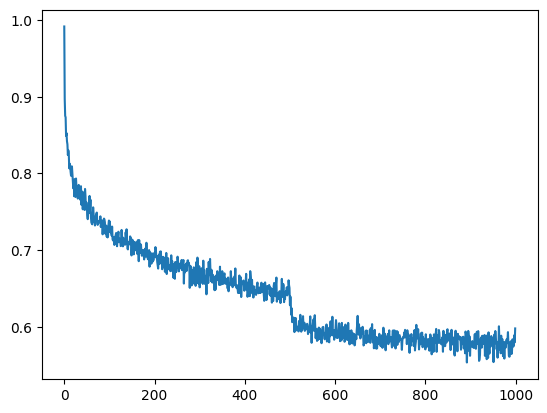

In [138]:
plt.plot(torch.tensor(lossi[:-1]).view(-1, 200).log().mean(1));

In [139]:
@torch.no_grad()
def getloss(X, Y):
    for layer in model.layers:
        if isinstance(layer, BatchNorm1D):
            layer.training = False
    logits = model(X)
    loss = F.cross_entropy(logits, Y)

    return loss.item()

In [140]:
print(getloss(Xtr, Ytr))
print(getloss(Xval, Yval))

1.7596012353897095
1.9949833154678345


- one layer, embed_size = 10, block_size = 8, n_hidden = 100 (total number of parameters: 11297): trainloss = 2.026, valloss = 2.074

- one layer, embed_size = 10, block_size = 8, n_hidden = 200 (total number of parameters: 22297): trainloss = 1.967, valloss = 2.048

- one layer, embed_size = 10, block_size = 8, n_hidden = 300 (total number of parameters: 33297): trainloss = 1.925, valloss = 2.030

- three layer (2,2,2), embed_size = 10, block_size = 8, n_hidden = 100 (total number of parameters: 45897): trainloss = 1.917, valloss = 2.018

- three layer (2,2,2), embed_size = 10, block_size = 8, n_hidden = 200 (total number of parameters: 171497): trainloss = 1.837, valloss = 1.992

- three layer (2,2,2), embed_size = 10, block_size = 8, n_hidden = 200  + 100000 more iterations (total number of parameters: 171497): trainloss = 1.760, valloss = 1.995

In [112]:
model.layers

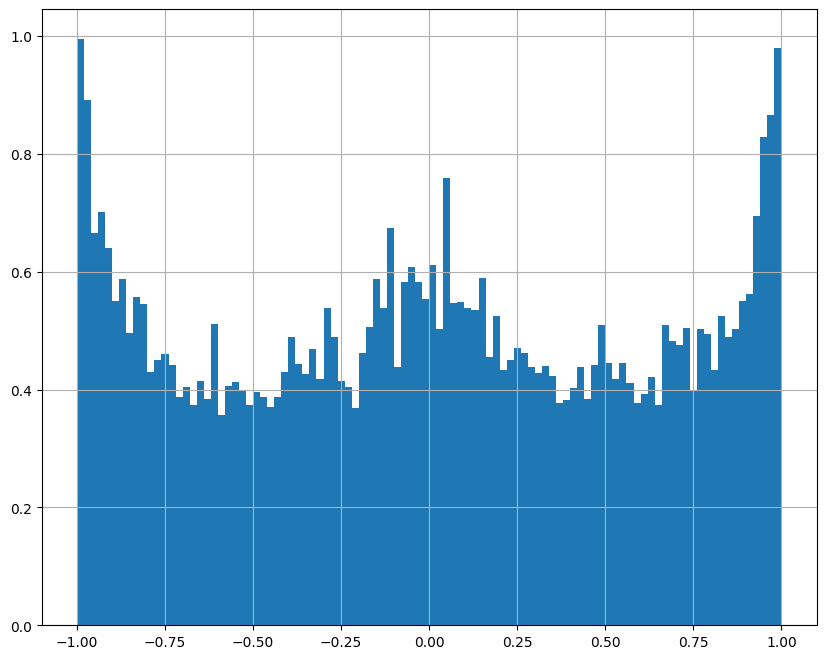

In [134]:
plt.figure(figsize = (10,8))
plt.hist(model.layers[-2].out.view(-1), density=True, bins=100);
plt.grid(True)

In [163]:
for _ in range(20):
    name = ''
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        name += itos[ix]
        context = context[1:] + [ix]
    print(name)

aylee
nycari
yumilia
haja
marcelina
lucy
bex
kaylani
marjord
luceyon
aliyah
syioura
kyleah
caslee
suleima
soland
shrethree
havonte
draylen
lynsolr
